# Notebook métricas de evaluación con RR Lyrae

Basado en Machine learning for physics and Astronomy, Viviana Acquaviva (2023)

En esta actividad trabajaremos con un problema de clasificación binaria: distinguir estrellas **RR Lyrae** de otras estrellas a partir de sus colores fotométricos.

### Los objetivos son
- entrenar un clasificador simple
- evaluar su rendimiento con distintas métricas
- interpretar una matriz de confusión
- comparar accuracy con precision, recall y F1
- discutir qué métrica conviene según el objetivo científico

### Contexto
Las RR Lyrae son estrellas variables pulsantes muy importantes en astronomía. En un catálogo grande, un clasificador puede ayudarnos a encontrar candidatas RR Lyrae, pero no basta con mirar solo el accuracy.


### Descripción de los datos
El set de datos que usará para esta tarea es sobre estrellas. Las características son colores en distintos filtros del [sistema ugriz de SDSS](https://www.physics.unlv.edu/~jeffery/astro/photometry/photometry_sdss.html), que son un indicador si la estrella emite luz más azul, verde, amarilla o roja. Queremos predecir a partir de estas características si la estrella es un tipo especial de estrella llamada variable RR Lyrae.

- Las características son los colores u-g, g-r, r-i, i-z
- El target es 0 (no RRLyrae) y 1 (RRLyrae)


In [1]:
import pandas as pd
import numpy as np

import sklearn.tree
from sklearn.tree import DecisionTreeClassifier #modelo
from sklearn.tree import plot_tree #visualizacion arbol
from sklearn.model_selection import train_test_split
from sklearn import metrics #métricas
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate #validación cruzada
from sklearn.model_selection import KFold, StratifiedKFold #validación cruzada

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay #matriz de confusión


from scipy import stats

In [2]:
from io import StringIO
from IPython.display import Image
import pydotplus
from sklearn.tree import export_graphviz

In [3]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

font = {'size': 8}

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=8)
matplotlib.rc('ytick', labelsize=8)
matplotlib.rcParams['figure.dpi'] = 300

pd.set_option('display.max_columns', 100) #Para poder visualizar todas las columnas del dataframe
pd.set_option('display.max_colwidth', 100)

## Primer paso: exploración de los datos

Siempre es importante hacer una análisis exploratorio del conjunto de datos que trabajaremos. Leemos el archivo como un dataframe y extraemos información básica

In [4]:
# Datos cargados localmente (sin Google Drive)

In [5]:
#cargamos los datos como arreglos numpy
features = np.loadtxt("RRLyrae_features_small.txt", delimiter=',')
targets  = np.loadtxt("RRLyrae_labels_small.txt",   delimiter=',')


In [6]:
columnas = ["u-g", "g-r", "r-i", "i-z"]
df = pd.DataFrame(features, columns=columnas)
df["RR_Lyrae"] = targets.astype(int)

df.head()

,u-g,g-r,r-i,i-z,RR_Lyrae
0,0.311,0.714,0.093,0.204,0
1,0.332,0.965,0.122,0.032,0
2,0.394,1.019,0.147,0.096,0
3,0.285,0.865,0.120,0.039,0
4,0.386,0.977,0.181,0.080,0


### Preguntas
1. ¿Este es un problema de clasificación o regresión?
2. ¿Es un problema binario o multiclase?
3. ¿Qué representa la variable objetivo?
4. ¿Las clases están balanceadas o desbalanceadas?
5. ¿Por qué esto podría ser importante al elegir una métrica de evaluación?

**Respuestas:**

1. Es un problema de **clasificación**.
2. Es **binario** (solo dos clases: RR Lyrae o no RR Lyrae).
3. La variable objetivo indica la naturaleza física de la estrella: si es (1) o no es (0) una estrella variable RR Lyrae.
4. Las clases están **desbalanceadas**, hay muchas más estrellas comunes que RR Lyrae.
5. Porque cuando las clases están desbalanceadas, el accuracy puede ser engañoso. Un clasificador que siempre predice la clase mayoritaria obtendría un accuracy alto, pero no detectaría ninguna RR Lyrae.


#### Haga una visualización de sólo dos columnas para revisar los colores de las RR Lyrae y las no RRLyrae

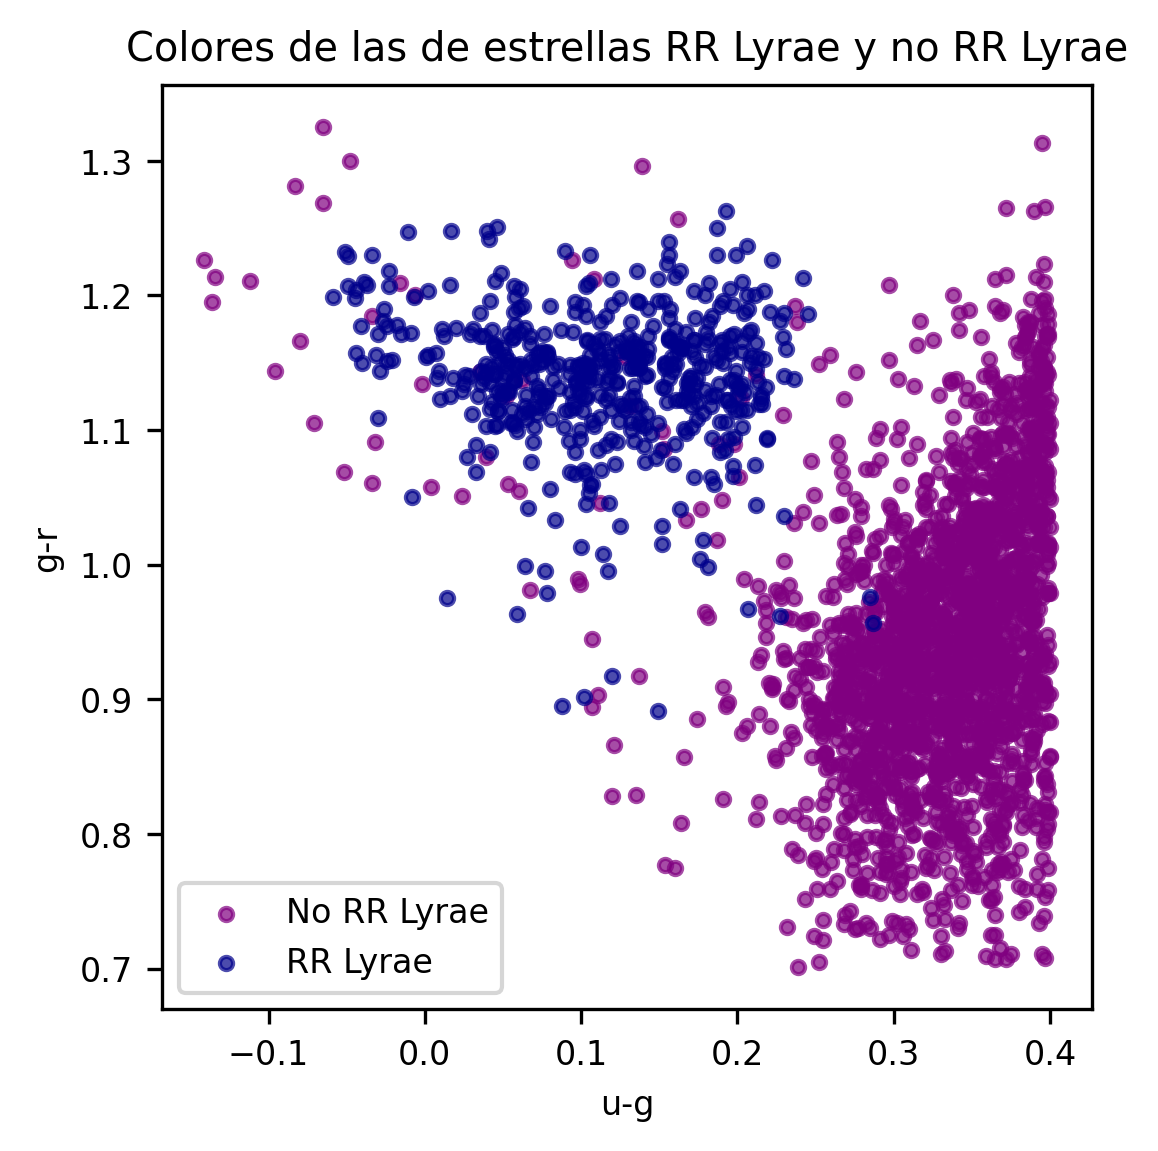

In [7]:
#complete la celda
plt.figure(figsize=(4,4))

plt.scatter(df[df['RR_Lyrae'] == 0]['u-g'], df[df['RR_Lyrae'] == 0]['g-r'],
            color='purple', s=10, alpha=0.7, label='No RR Lyrae')
plt.scatter(df[df['RR_Lyrae'] == 1]['u-g'], df[df['RR_Lyrae'] == 1]['g-r'],
            color='darkblue', s=10, alpha=0.7, label='RR Lyrae')

plt.xlabel('u-g')
plt.ylabel('g-r')
plt.title('Colores de las de estrellas RR Lyrae y no RR Lyrae')
plt.legend()
plt.show()


### Pregunta
1. ¿Se observan regiones donde las clases parecen separarse?
2. A simple vista, ¿esperarías que un árbol de decisión funcione razonablemente bien?

**Respuestas:**

1. Si, se observa que existe una región con alta densidad de estrellas comunes (No RR Lyrae) en la parte inferior del gráfico, mientras que las RR Lyrae tienden a concentrarse en otra zona. Existe una separación parcial entre las clases.
2. Si, ya que las clases presentan cierta separabilidad espacial que un árbol de decisión, mediante cortes rectangulares, podría aprovechar razonablemente bien.


#### Separe los datos en entrenamiento y prueba

In [8]:
X = df[["u-g", "g-r", "r-i", "i-z"]]
y = df["RR_Lyrae"]

In [9]:
#complete la celda
X_train, X_test, y_train, y_test =train_test_split(X,y,test_size=0.3, random_state=42)
X_train.shape

(1738, 4)

### Antes de continuar

Las clases en este problema no están perfectamente balanceadas.

Piense en la forma en que podríamos separar los datos en entrenamiento y prueba, y responda:

1. ¿Qué problema podría ocurrir si hacemos la partición de manera completamente aleatoria, sin preocuparnos por la proporción de clases?
2. ¿Por qué eso podría afectar la evaluación del modelo?
3. ¿Qué tipo de precaución cree que sería razonable tomar al construir los conjuntos de entrenamiento y prueba en este caso?

**Respuestas:**

1. Yo creo que las clases están desbalanceadas y la partición es aleatoria, alguno de los conjuntos (entrenamiento o prueba) podría terminar con muy pocas o incluso ninguna instancia de la clase de menor proporcion.
2. El modelo será poco representativa para esa clase si el conjunto de prueba no contiene suficientes ejemplos de la clase minoritaria. Las métricas como precision no tendrán significado estadístico.
3. Lo que garantiza que la proporción de clases se mantenga similar en ambos conjuntos es usar la precaución de**estratificación**


In [10]:
model_tree = DecisionTreeClassifier(random_state=42)
model_tree.fit(X_train, y_train)
#entrene el modelo y genere las predicciones
y_pred=model_tree.predict(X_test)

In [11]:
#calcular el número de niveles del árbol
model_tree.get_depth()

14

#### Visualicemos el árbol

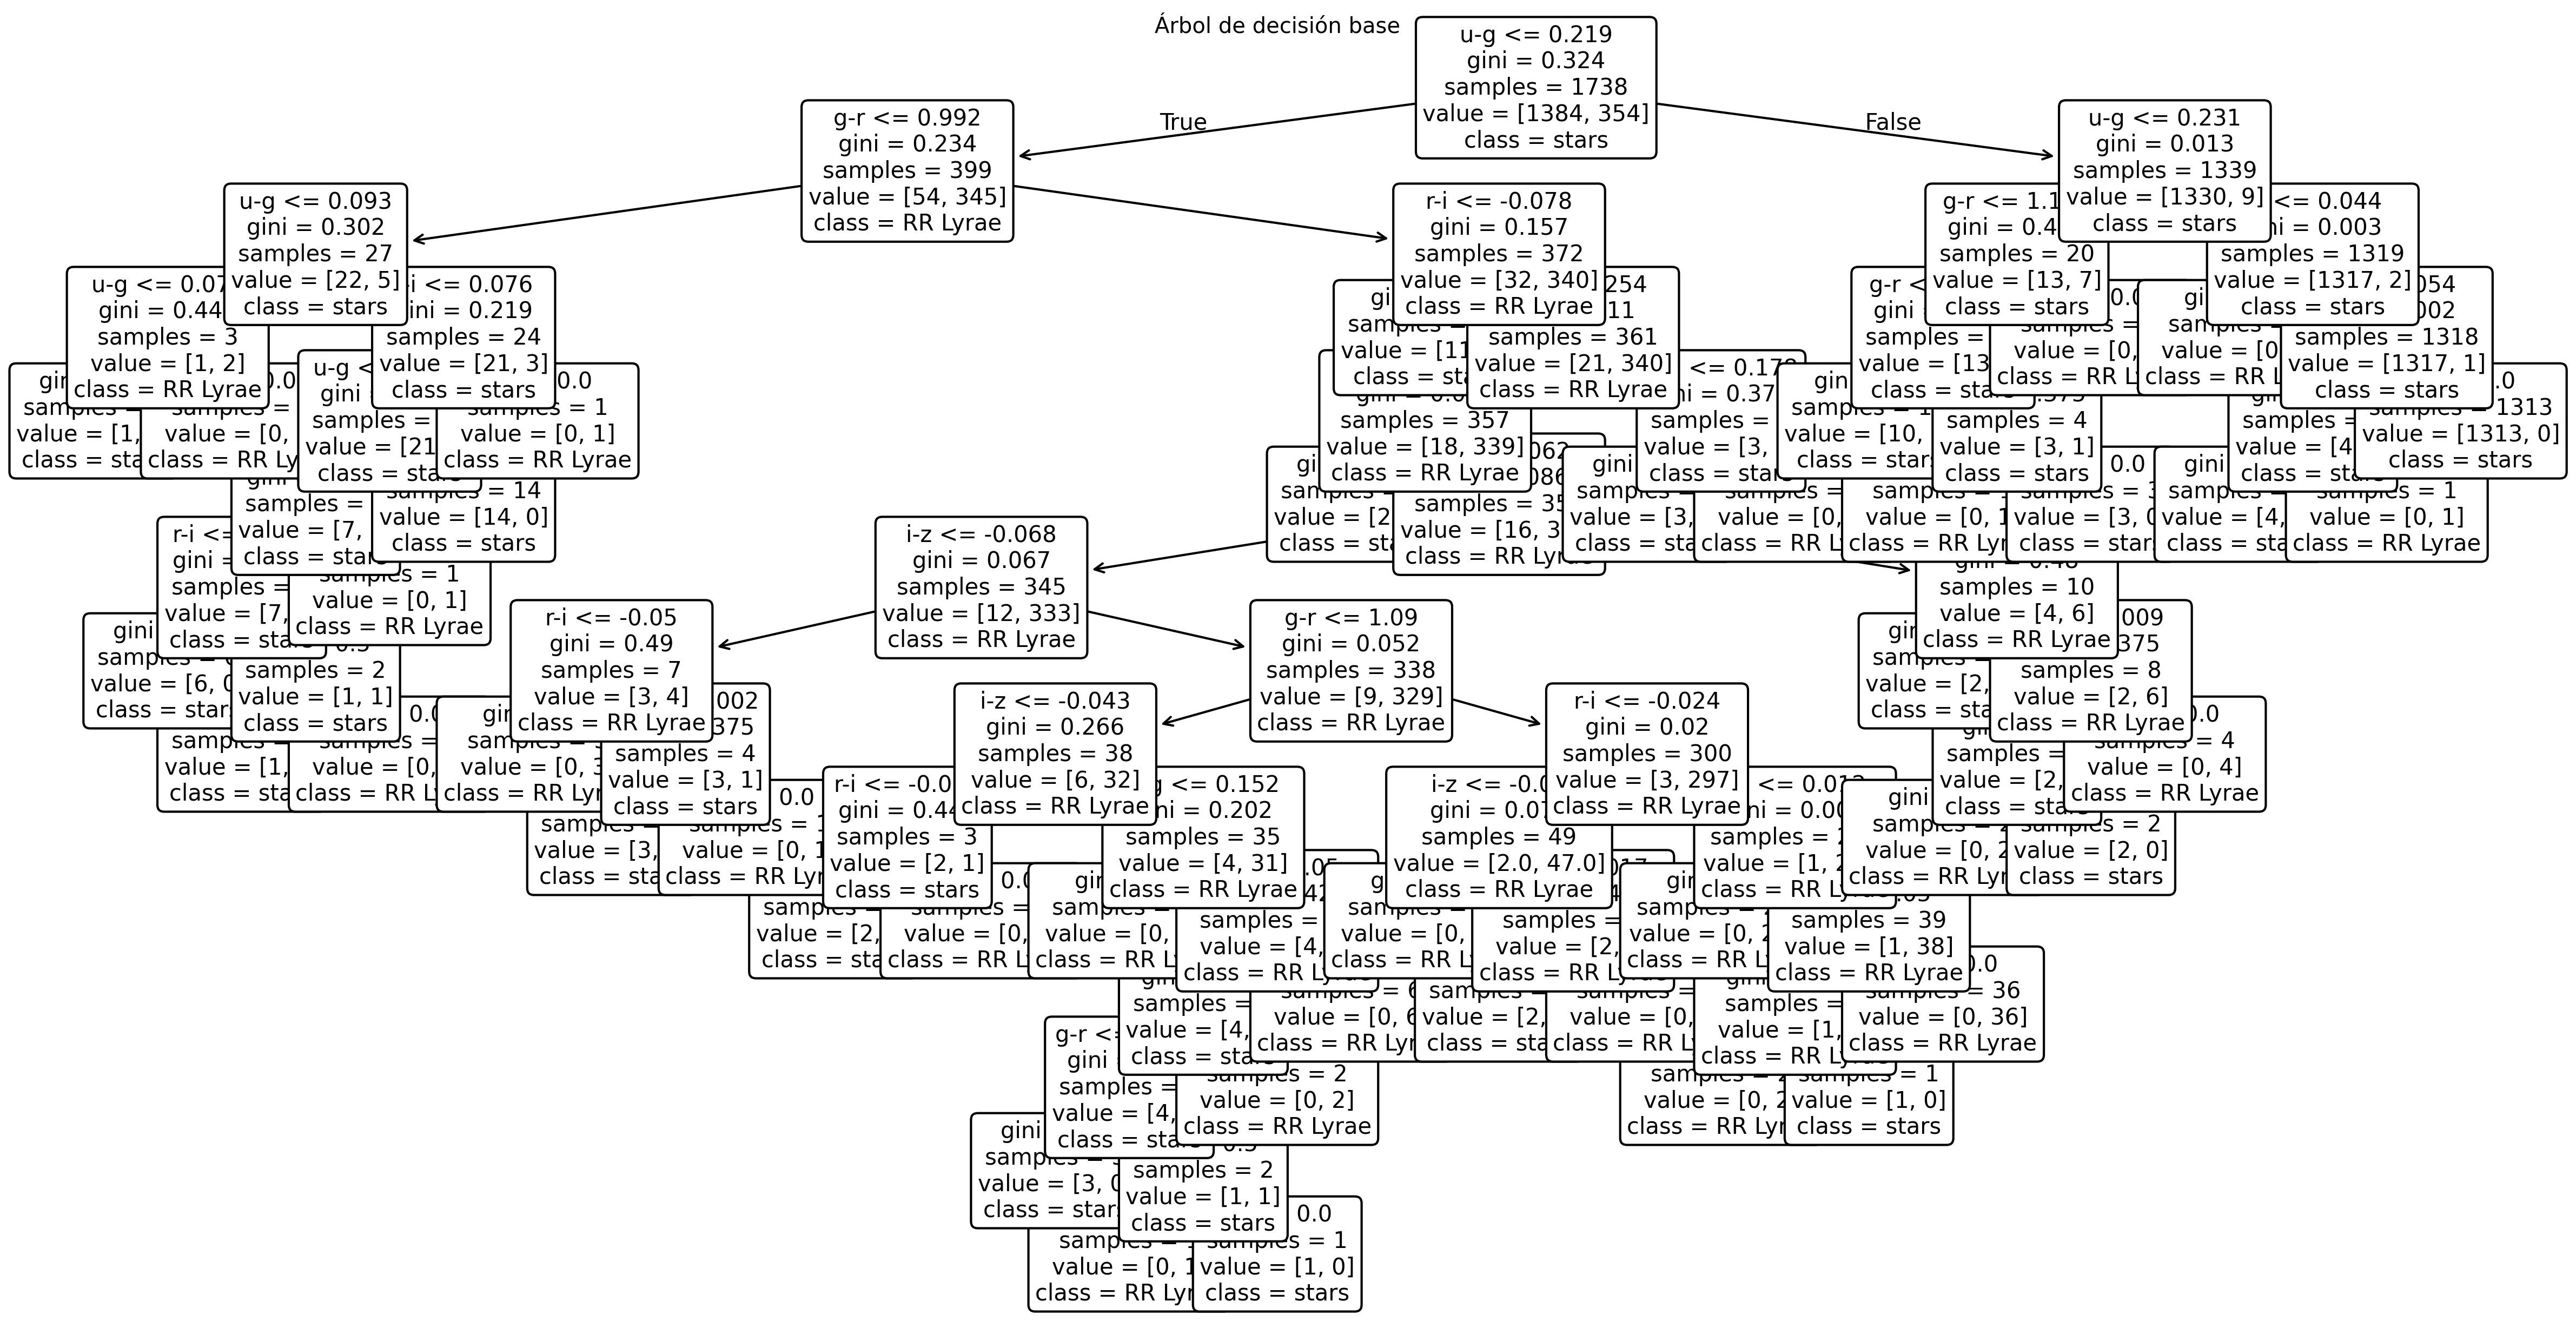

In [12]:
plt.figure(figsize=(20,10))

plot_tree(
    model_tree,
    feature_names=X.columns,
    class_names=["stars", "RR Lyrae"],
    filled=False,
    rounded=True,
    #max_depth=3,
    fontsize=10
)

plt.title("Árbol de decisión base")
plt.show()

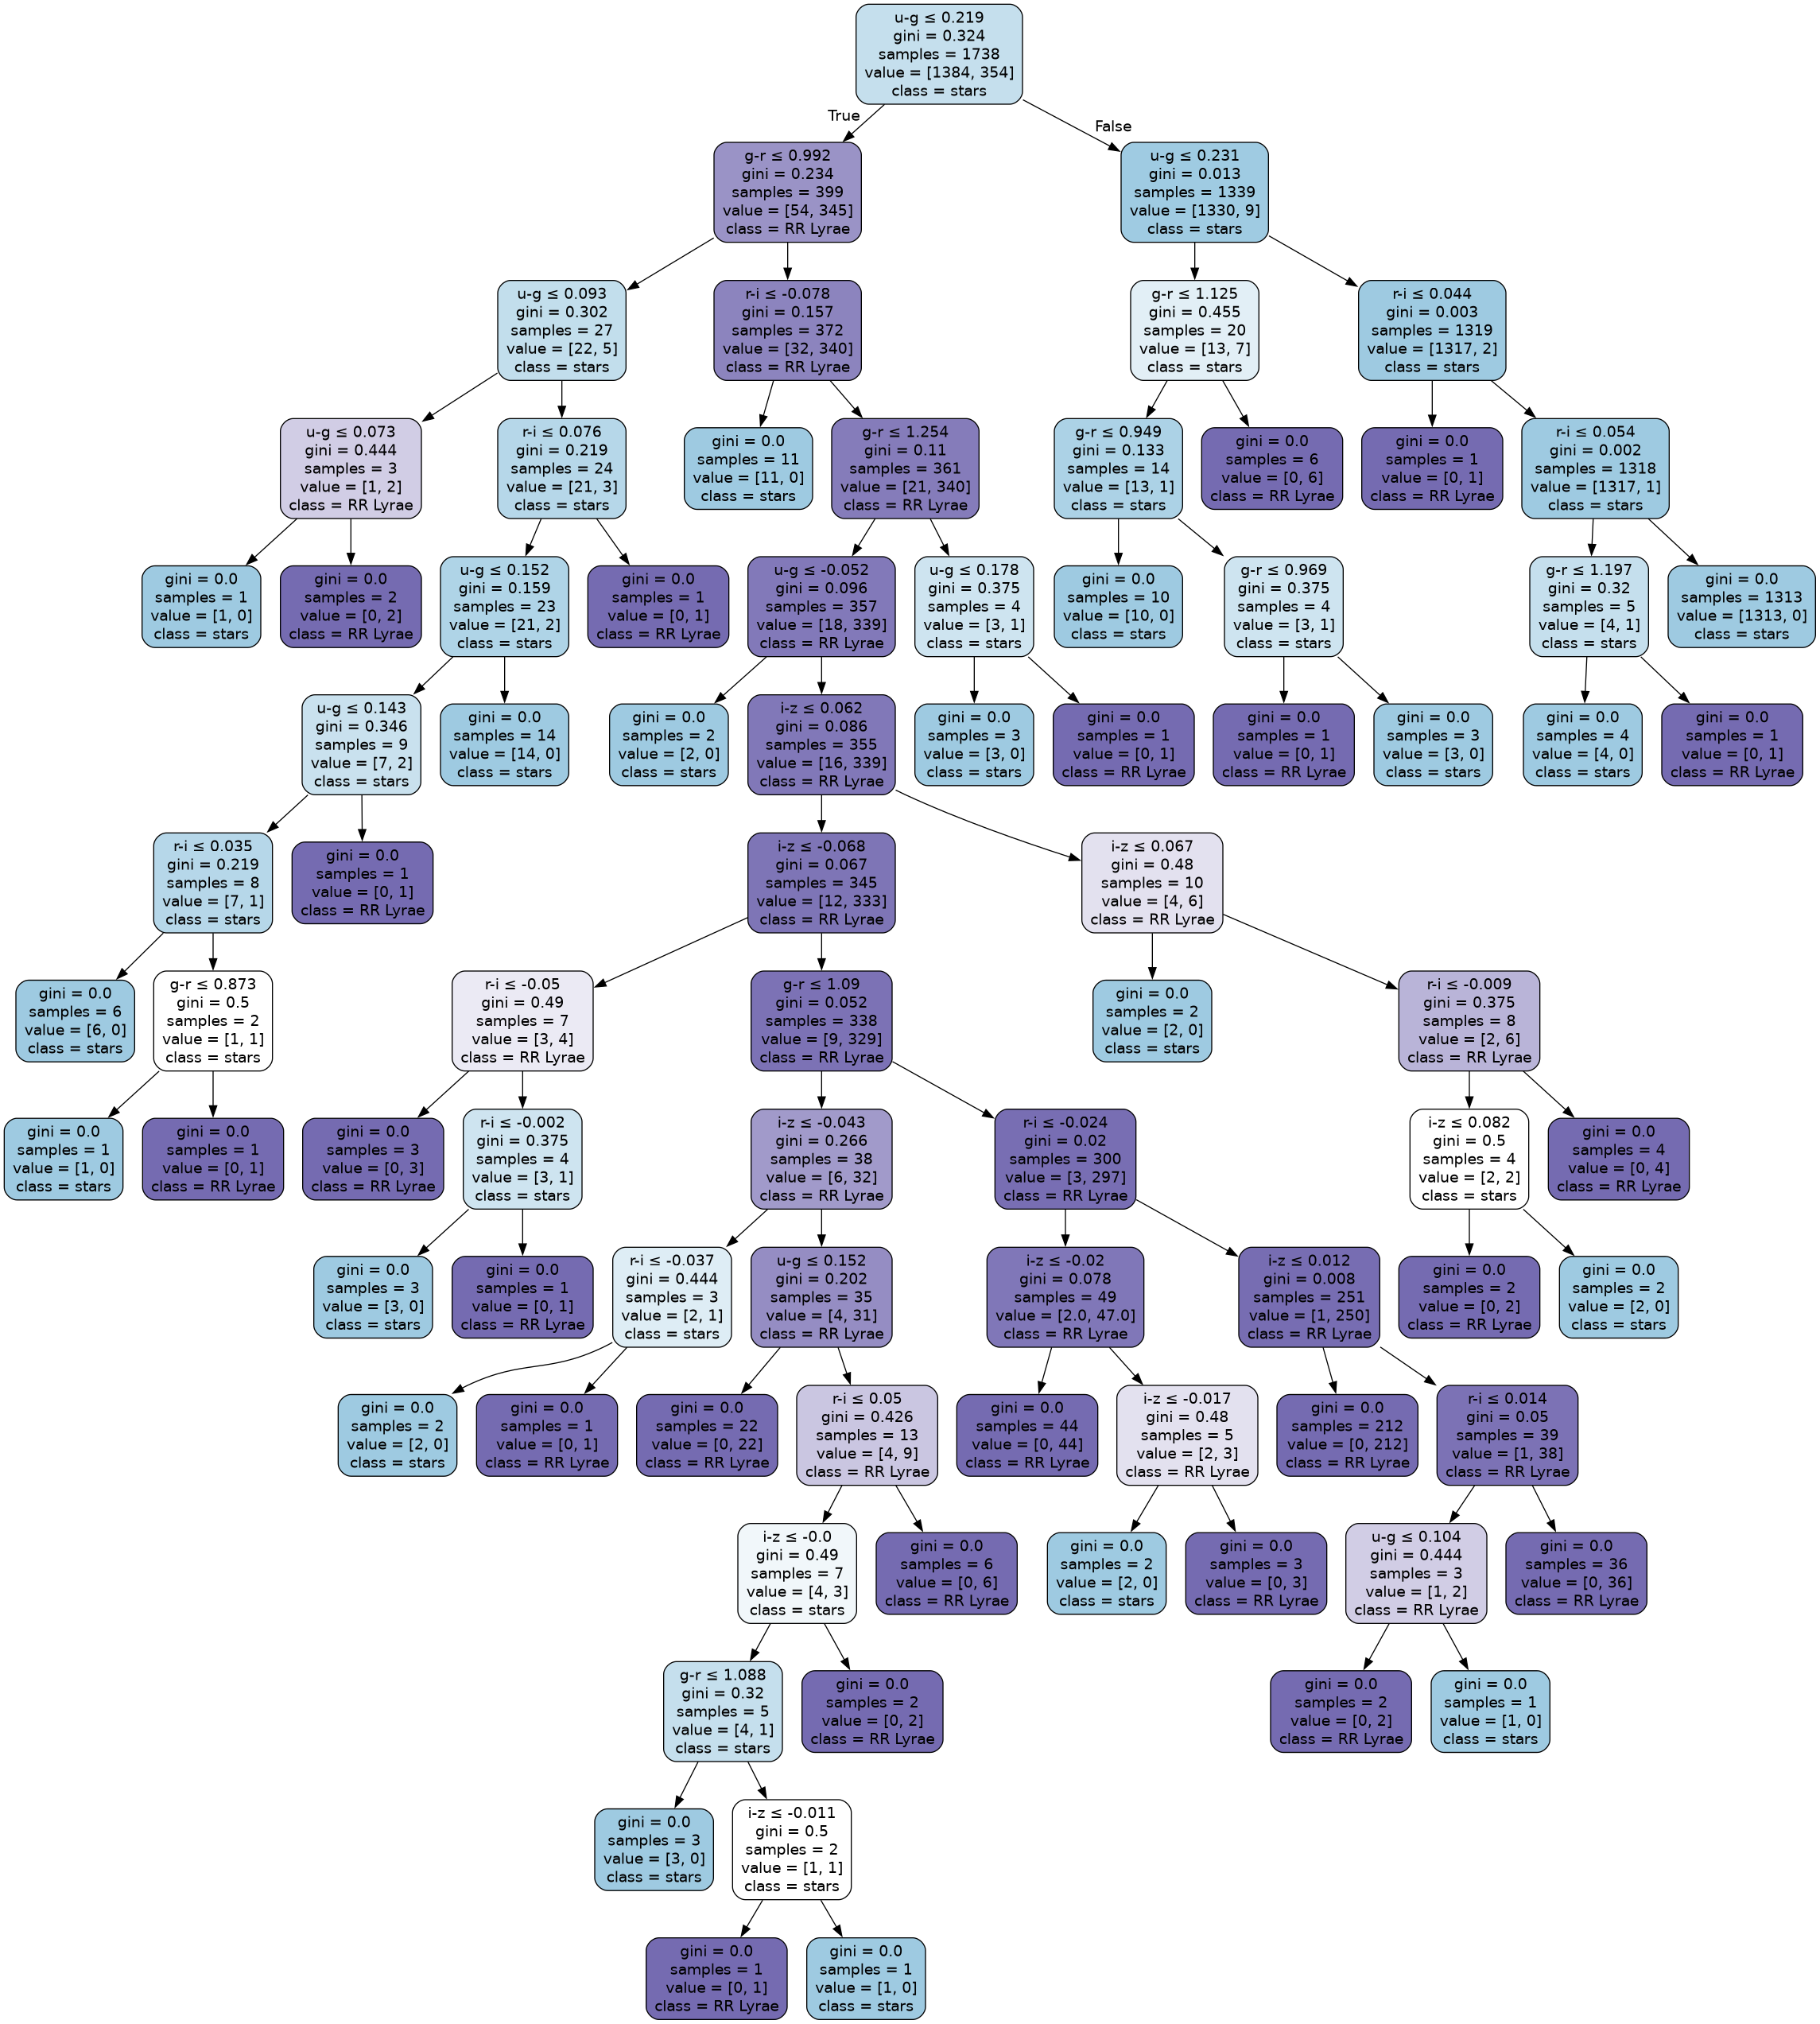

In [13]:
# Recordatorio: Las características siempre se permutan aleatoriamente en cada división.
# Por lo tanto, la mejor división encontrada puede variar, incluso con los mismos datos
# de entrenamiento y max_features=n_features, si la mejora del criterio es idéntica
# para varias divisiones enumeradas durante la búsqueda de la mejor división.
# Para obtener un comportamiento determinista durante el ajuste, random_state debe estar fijo.

dot_data = StringIO()

export_graphviz(
    model_tree,
    out_file=dot_data,
    feature_names=['u-g', 'g-r', 'r-i', 'i-z'],
    class_names=['stars', 'RR Lyrae'],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = pydotplus.graph_from_dot_data(dot_data.getvalue().replace("\n", ""))
nodes = graph.get_node_list()

for node in nodes:
    if node.get_label() and 'value = [' in node.get_label():

        values = [float(ii) for ii in node.get_label().split('value = [')[1].split(']')[0].split(',')]
        values = [int(255 * v / sum(values)) for v in values]

        if values[0] > values[1]:
            alpha = int(values[0] - values[1])
            alpha = '{:02x}'.format(alpha)
            color = '#9ecae1' + str(alpha)   # turquesa
        else:
            alpha = int(values[1] - values[0])
            alpha = '{:02x}'.format(alpha)
            color = '#756bb1' + str(alpha)   # magenta

        node.set_fillcolor(color)

Image(graph.create_png())

### Preguntas

Observe la estructura del árbol y responda brevemente:

1. ¿El árbol parece muy simple o bastante complejo? Justifique a partir del número de niveles o divisiones.
2. ¿Qué desventaja podría tener un árbol demasiado grande en un problema como este?

**Respuestas:**

1. El árbol se ve bastante **complejo**, tiene 14 niveles de profundidad con muchas divisiones. Esto indica que el modelo aprendió particiones muy finas de los datos.
2. Es posible que un árbol demasiado grande tiende a **sobreajustarse (overfitting)**: memoriza los datos de entrenamiento incluyendo el ruido, por lo que generaliza mal a datos nuevos. Esto se refleja en un accuracy de entrenamiento casi perfecto pero un desempeño menor en test.


#### Miremos las métricas accuracy para set de entrenamiento y prueba

In [14]:
print(metrics.accuracy_score(y_train, model_tree.predict(X_train))) #train score

print(metrics.accuracy_score(y_test, model_tree.predict(X_test))) #test score

1.0
0.9651006711409396


#### Otras métricas

In [15]:
print("Precision:", metrics.precision_score(y_test, y_pred))
print("Recall   :", metrics.recall_score(y_test, y_pred))
print("F1-score :", metrics.f1_score(y_test, y_pred))

Precision: 0.8759124087591241
Recall   : 0.9302325581395349
F1-score : 0.9022556390977443


In [16]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[599,  17],
       [  9, 120]])

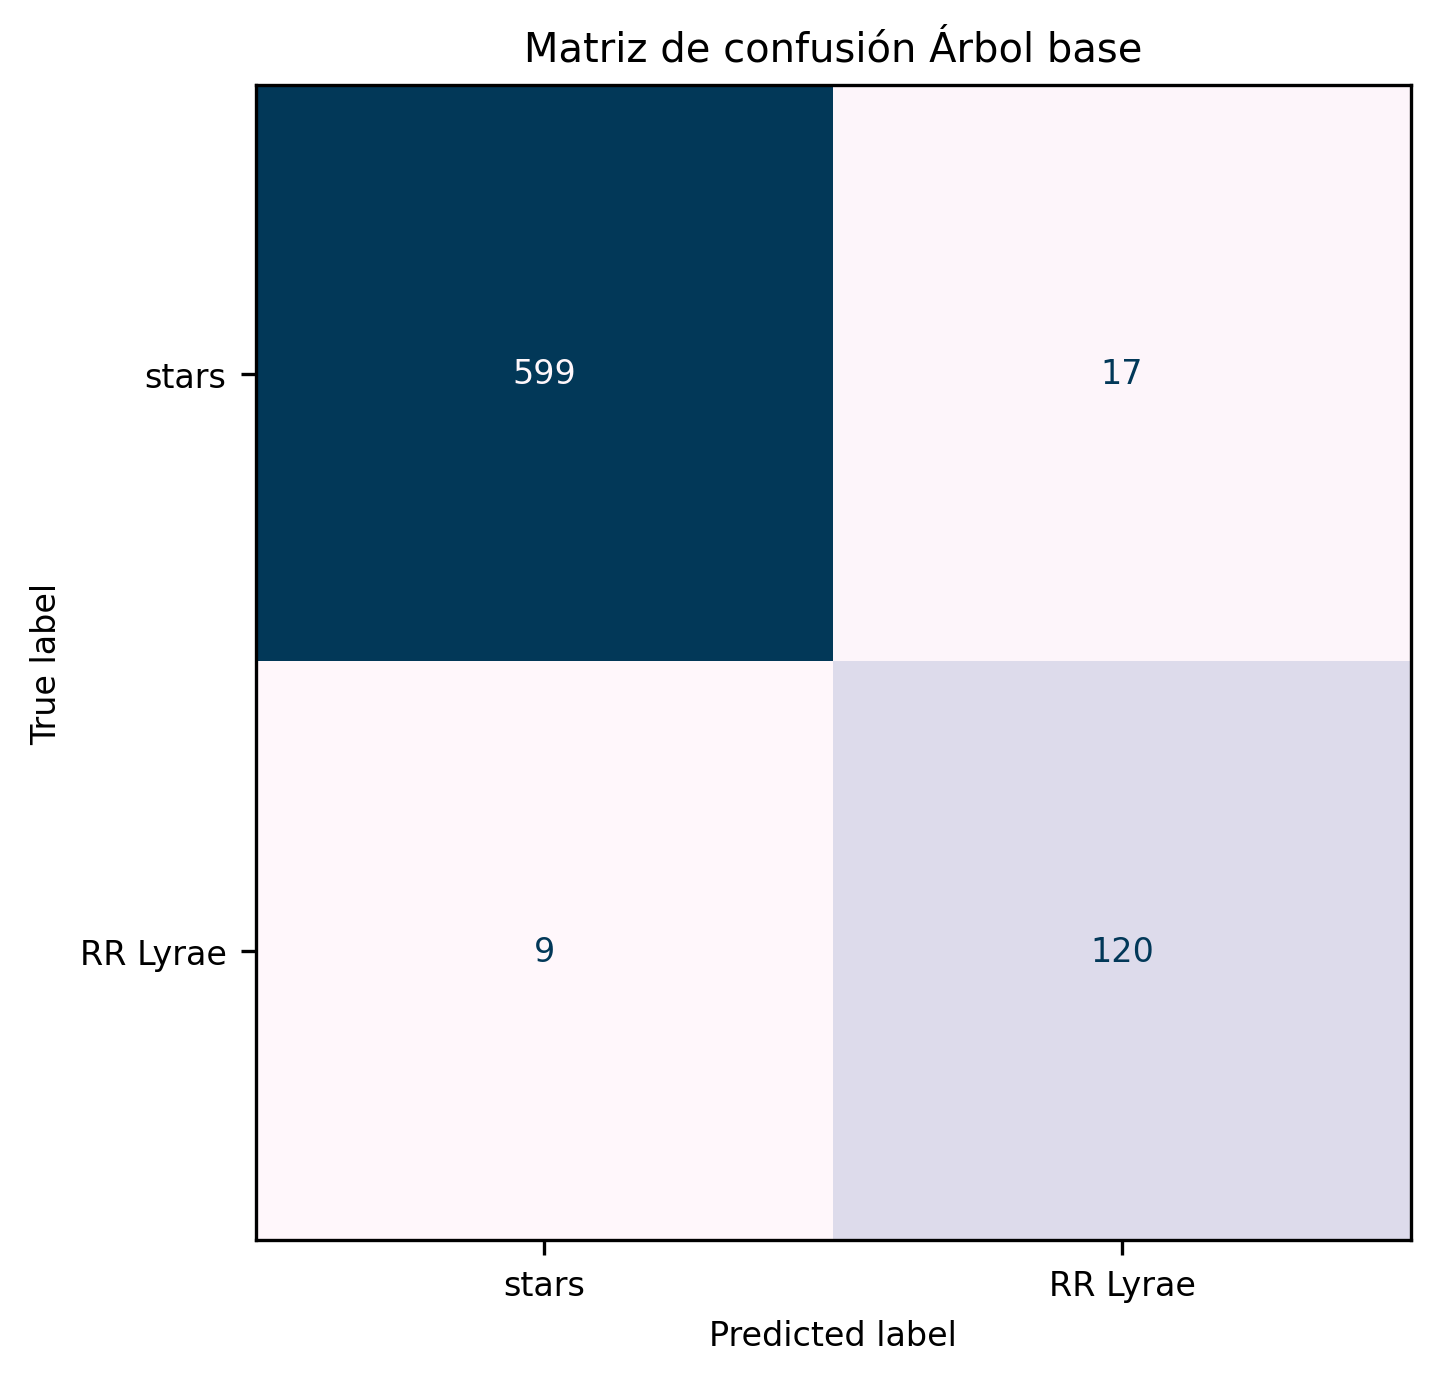

In [17]:
fig, ax = plt.subplots(figsize=(5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["stars", "RR Lyrae"])
disp.plot(cmap="PuBu", ax=ax, colorbar=False)

plt.title("Matriz de confusión Árbol base")
plt.show()

#### A partir de la matriz de confusión obtenida:
1.  Identifique los valores de:
   - verdaderos positivos (TP)
   - verdaderos negativos (TN)
   - falsos positivos (FP)
   - falsos negativos (FN)
2. Calcule las métricas "a mano"

**Identificación (a partir de la matriz de confusión):**

- **TP** = 120 (predicho RR Lyrae, real RR Lyrae)
- **TN** = 599 (predicho No RR Lyrae, real No RR Lyrae)
- **FP** = 17  (predicho RR Lyrae, real No RR Lyrae)
- **FN** = 9   (predicho No RR Lyrae, real RR Lyrae)


In [18]:
# Cálculo manual de métricas
TP = 120
TN = 599
FP = 17
FN = 9

Precision = TP / (TP + FP)
Recall    = TP / (TP + FN)
F1        = 2 * (Precision * Recall) / (Precision + Recall)

print(f"Precision (manual): {Precision:.4f}")
print(f"Recall    (manual): {Recall:.4f}")
print(f"F1-score  (manual): {F1:.4f}")


Precision (manual): 0.8759
Recall    (manual): 0.9302
F1-score  (manual): 0.9023


### Preguntas
1. Explique con sus palabras qué significa, en este problema:
   - un falso positivo
   - un falso negativo

2. Si el objetivo científico fuera encontrar la mayor cantidad posible de RR Lyrae, ¿qué tipo de error preocuparía más?

3. Si el objetivo fuera construir una muestra final más limpia, ¿qué tipo de error preocuparía más?

**Respuestas:**

1. 
   - **Falso positivo:** el modelo predice que una estrella es una RR Lyrae, pero en realidad no lo es. Se contamina la muestra con objetos incorrectos.
   - **Falso negativo:** el modelo predice que una estrella no es una RR Lyrae, pero en realidad si lo es. Se pierde una candidata verdadera.

2. Si el objetivo es encontrar la **mayor cantidad posible** de RR Lyrae, el error más preocupante es el **falso negativo**: perder estrellas RR Lyrae reales. La métrica relevante es el **Recall**.

3. Si el objetivo es una **muestra limpia** con pocos contaminantes, el error más preocupante es el **falso positivo**: incluir objetos que no son RR Lyrae. La métrica relevante es la **Precision**.


#### Todo parece funcionar bien, pero sólo hicimos un split. Necesitamos que el resultados sea robusto. Para esto, implementaremos Cross-validation usando [k-fold](https://scikit--learn-org.translate.goog/stable/modules/generated/sklearn.model_selection.KFold.html?_x_tr_sl=en&_x_tr_tl=es&_x_tr_hl=es&_x_tr_pto=tc)

In [19]:
# Esta es la versión estándar. Importante: no baraja los datos, por lo que si tus
# ejemplos positivos están todos al principio o al final, podría llevar a resultados
# desastrosos.

cv1 = KFold(n_splits = 5)

#Esta es la versión 2: se ha añadido el barajado (¡recomendado!)

cv2 = KFold(shuffle = True, n_splits = 5, random_state=5)

# LA ESTRATIFICACIÓN asegura que las distribuciones de clases en cada división se
# asemejen a las del conjunto de datos completo.

cv3 = StratifiedKFold(shuffle = True, n_splits = 5, random_state=5)


### Efecto de la estratificación: veamos el conteo de clases en cada conjunto de divisiones.

In [20]:
cv1.split(X, y)

<generator object _BaseKFold.split at 0x7f2b619af9a0>

In [21]:
for train, test in cv1.split(X, y):
    print('train -  {}   |   test -  {}'.format(
        np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1503  483]   |   test -  [497]
train -  [1503  483]   |   test -  [497]
train -  [1503  483]   |   test -  [497]
train -  [1504  483]   |   test -  [496]
train -  [1987]   |   test -  [ 13 483]


In [22]:
for train, test in cv2.split(X, y):
    print('train -  {}   |   test -  {}'.format(
        np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1600  386]   |   test -  [400  97]
train -  [1610  376]   |   test -  [390 107]
train -  [1587  399]   |   test -  [413  84]
train -  [1599  388]   |   test -  [401  95]
train -  [1604  383]   |   test -  [396 100]


In [23]:
for train, test in cv3.split(X, y):
    print('train -  {}   |   test -  {}'.format(
        np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1600  386]   |   test -  [400  97]
train -  [1600  386]   |   test -  [400  97]
train -  [1600  386]   |   test -  [400  97]
train -  [1600  387]   |   test -  [400  96]
train -  [1600  387]   |   test -  [400  96]


### La función [`cross_validate`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html#sklearn.model_selection.cross_validate) proporciona los puntajes (especificados por el parámetro de evaluación elegido), en forma de diccionario.

In [24]:
scores1 = cross_validate(model_tree, X, y, cv = cv1, scoring = 'accuracy')

scores2 = cross_validate(model_tree, X, y, cv = cv2, scoring = 'accuracy')

scores3 = cross_validate(model_tree, X, y, cv = cv3, scoring = 'accuracy')


In [25]:
scores3

{'fit_time': array([0.00525355, 0.00518584, 0.00564814, 0.00632858, 0.00522423]),
 'score_time': array([0.00180817, 0.00193024, 0.00195551, 0.00210214, 0.00177526]),
 'test_score': array([0.9778672 , 0.96981891, 0.96780684, 0.97379032, 0.96572581])}

Solo nos interesa el 'test_score'

#### Calculamos el promedio y $\sigma$

In [26]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['test_score'].std()))

0.786 0.380


In [27]:
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['test_score'].std()))

0.965 0.012


In [28]:
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['test_score'].std()))

0.971 0.004


La validación cruzada sin barajar (`cv1`) produce un resultado muy inestable, con una desviación estándar extremadamente alta. Esto ocurre porque los datos están ordenados por clase, de modo que algunos folds no representan bien el problema completo.

Al activar el barajado (`cv2`), el rendimiento mejora drásticamente y la dispersión disminuye. Sin embargo, el método que resulta más apropiado para este problema es `StratifiedKFold` (`cv3`), ya que además de mezclar los datos, conserva aproximadamente la proporción de clases en cada fold.

En problemas de clasificación desbalanceada, esta última estrategia suele ser la más recomendable.

In [29]:
scores1 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv1, scoring = 'recall')

scores2 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv2, scoring = 'recall')

scores3 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv3, scoring = 'recall')

/home/jorgeluis/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/jorgeluis/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/jorgeluis/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/jorgeluis/miniconda3/lib/python

In [30]:
scores1 = cross_validate(model_tree, X, y, cv = cv1, scoring = 'recall')

scores2 = cross_validate(model_tree, X, y, cv = cv2, scoring = 'recall')

scores3 = cross_validate(model_tree, X, y, cv = cv3, scoring = 'recall')


/home/jorgeluis/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/jorgeluis/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/jorgeluis/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/jorgeluis/miniconda3/lib/python

### ¿Por qué aparece este warning?

En algunos folds generados por `KFold` sin barajado, el conjunto de prueba contiene solo ejemplos de una clase. En ese caso, el recall de la clase positiva (RR Lyrae) no puede calcularse, porque no hay positivos reales en ese fold.

Esto muestra que una estrategia de partición inadecuada puede hacer que la evaluación sea inestable, engañosa o incluso inválida.

#### También extraeremos los train scores, que nos servirán cuando estemos diagnosticando el modelo a través de bias vs variance.¶

In [31]:
scores1 = cross_validate(model_tree, X, y, cv = cv1, scoring = 'recall',
                         return_train_score = True)

scores2 = cross_validate(model_tree, X, y, cv = cv2, scoring = 'recall',
                         return_train_score = True)

scores3 = cross_validate(model_tree, X, y, cv = cv3, scoring = 'recall',
                         return_train_score = True)


/home/jorgeluis/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/jorgeluis/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/jorgeluis/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/jorgeluis/miniconda3/lib/python

In [32]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['train_score'].mean()))
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['train_score'].mean()))
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['train_score'].mean()))

nan nan
0.914 1.000
0.932 1.000


### La función  `cross_validate` es útil para calcular el puntaje, pero no produce etiquetas predichas.

#### Estas pueden obtenerse utilizando la función [`cross_val_predict`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_predict.html), que guarda las predicciones para cada uno de los k-folds de prueba y las compila juntas.


In [33]:
model1 = model_tree

y_cv3 = cross_val_predict(model1, X, y, cv = cv3)
# Estas son las predicciones,
# y son independientes del parámetro de evaluación

In [34]:
metrics.confusion_matrix(targets,y_cv3)

array([[1961,   39],
       [  33,  450]])

### Sin embargo, las cosas pueden cambiar si uso un esquema de validación cruzada diferente:

In [35]:
model2 = model_tree

y_cv2 = cross_val_predict(model2, X, y, cv = cv2)


In [36]:
np.sum(y_cv3-y_cv2)

np.int64(4)

In [37]:
np.sum(y_cv2)

np.int64(485)

In [38]:
np.sum(y_cv3 != y_cv2) #comparando las predicciones

np.int64(52)

In [39]:
metrics.confusion_matrix(targets,y_cv2)

array([[1956,   44],
       [  42,  441]])

In [40]:
metrics.confusion_matrix(targets,y_cv3)

array([[1961,   39],
       [  33,  450]])

In [41]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=5,
                        n_jobs=-1, train_sizes=np.linspace(0.2, 1.0, 5), scoring = 'accuracy'):
    """
    Generate a simple plot of the test and training learning curve.

    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
        An object of that type which is cloned for each validation.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features), optional
        Target relative to X for classification or regression;
        None for unsupervised learning.

    ylim : tuple, shape (ymin, ymax), optional
        Defines minimum and maximum yvalues plotted.

    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:
          - None, to use the default 3-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used here.

    n_jobs : int or None, optional (default=None)
        Number of jobs to run in parallel.
        ``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.
        ``-1`` means using all processors. See :term:`Glossary <n_jobs>`
        for more details.

    train_sizes : array-like, shape (n_ticks,), dtype float or int
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve. If the dtype is float, it is regarded as a
        fraction of the maximum size of the training set (that is determined
        by the selected validation method), i.e. it has to be within (0, 1].
        Otherwise it is interpreted as absolute sizes of the training sets.
        Note that for classification the number of samples usually have to
        be big enough to contain at least one sample from each class.
        (default: np.linspace(0.1, 1.0, 5))
    """
    plt.figure(figsize=(10,6))
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel(str(scoring))

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring = scoring, shuffle=True, random_state=42)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Test score from cross-validation")

    plt.legend(loc="best")
    return plt

In [42]:
model = model_tree

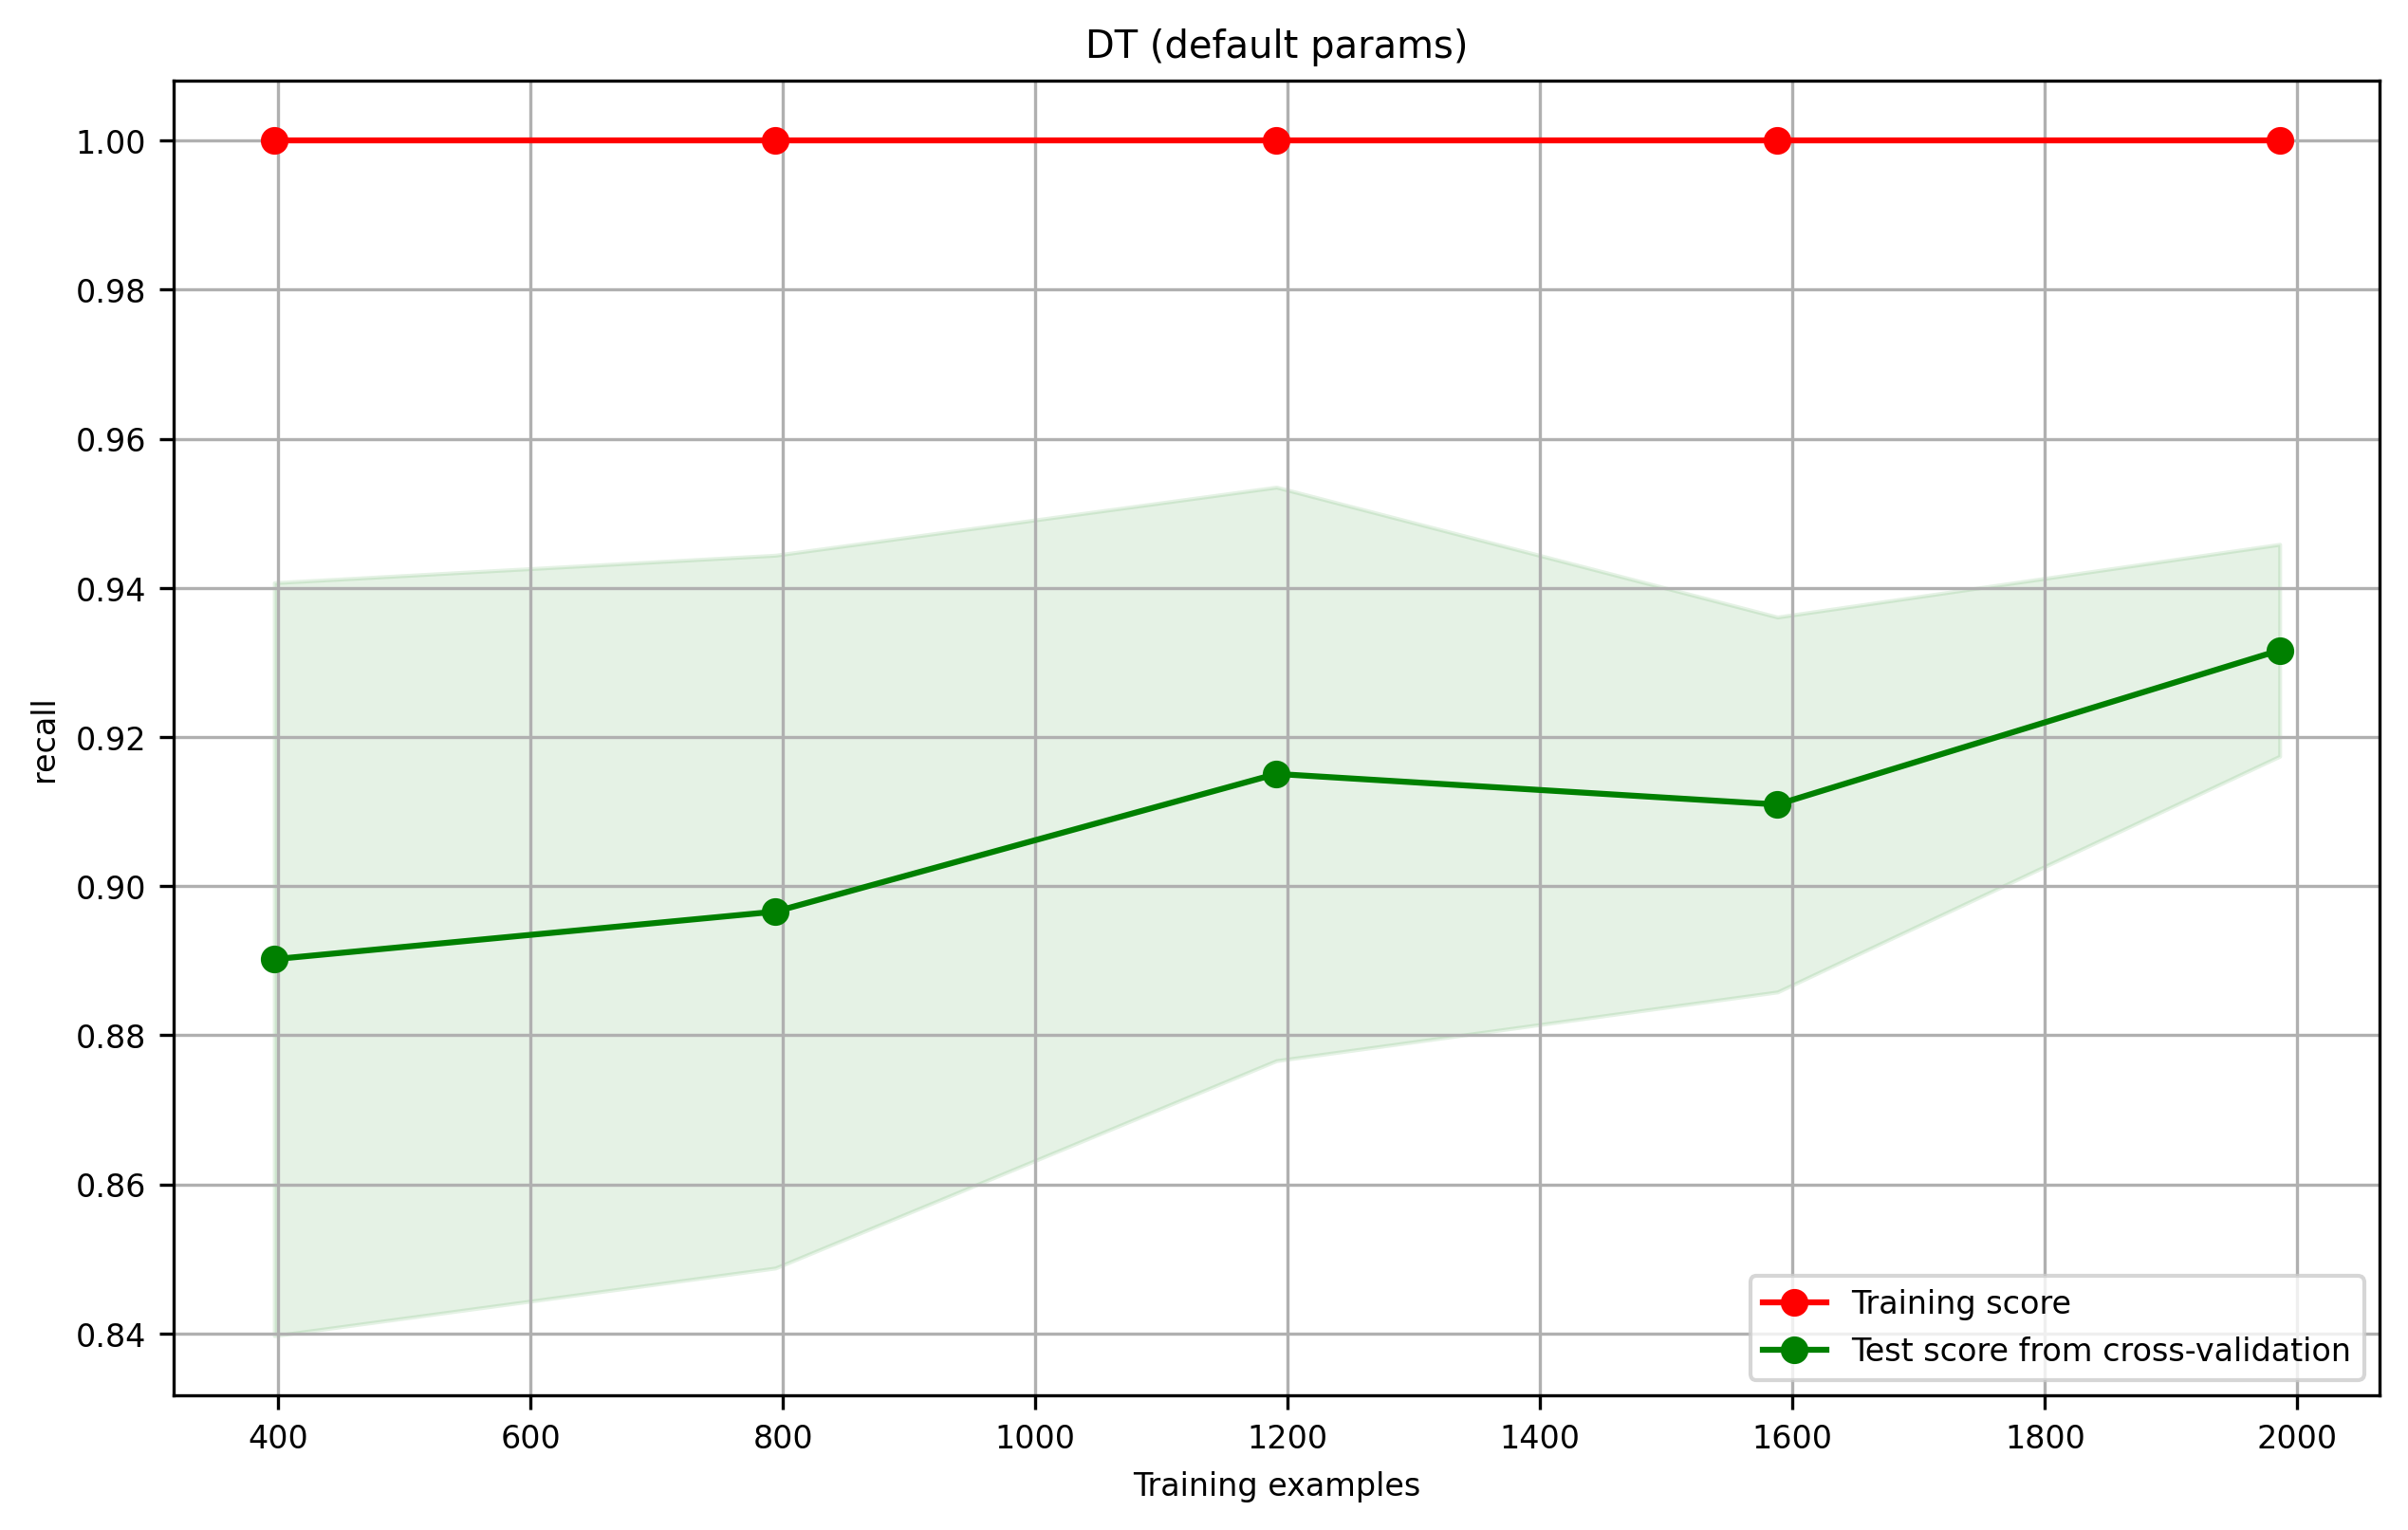

In [43]:
plot_learning_curve(model, 'DT (default params)', X, y,  cv = cv3, scoring = 'recall');

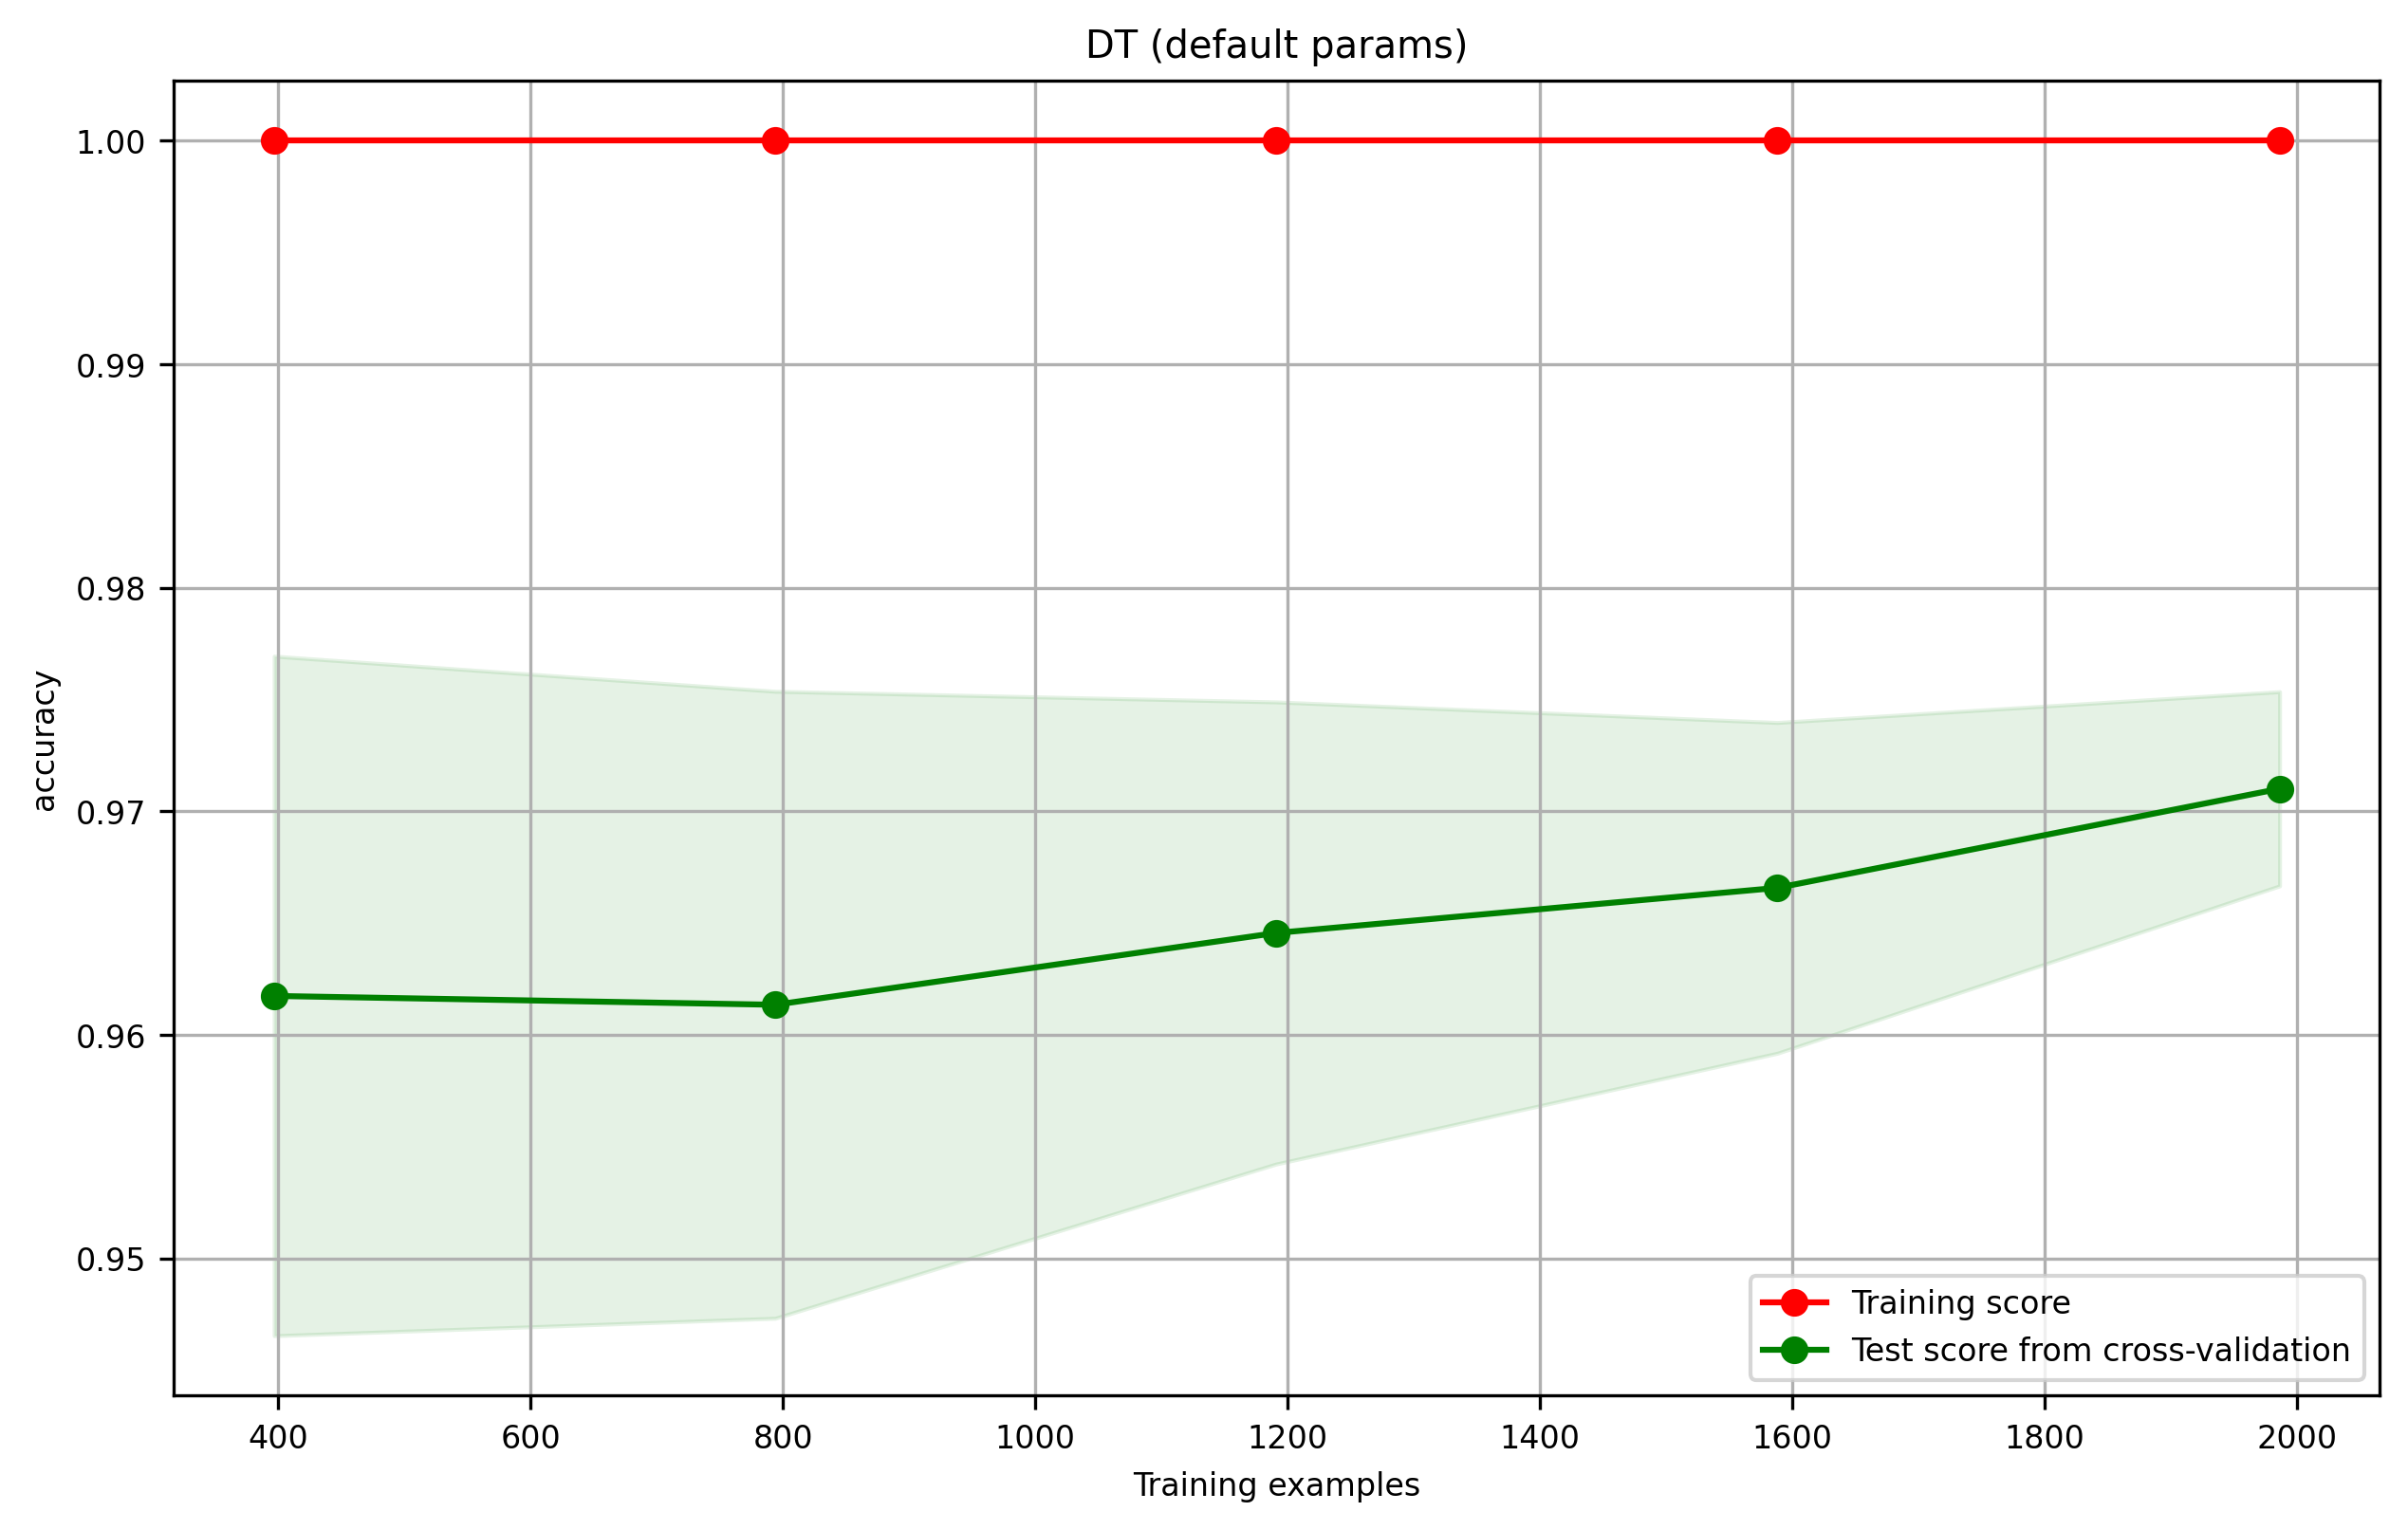

In [44]:
plot_learning_curve(model, 'DT (default params)', X, y,  cv = cv3, scoring = 'accuracy');

### **Preguntas**

Responda brevemente:

1. ¿Existe una brecha entre la curva de entrenamiento y la de validación? ¿Qué sugiere eso?
2. ¿El rendimiento de validación mejora al agregar más ejemplos?
3. ¿Hablaría aquí de alto sesgo, alta varianza o sobreajuste moderado? Justifique.
4. Escriba una conclusión general sobre el comportamiento del árbol base a partir de estas curvas.


**Respuestas:**

1. Si, se nota claramente una brecha entre ambas curvas. La curva de entrenamiento se mantiene cercana a 1.0 mientras la de validación es más baja. Esto sugiere que el modelo memoriza los datos de entrenamiento pero no generaliza bien.

2. No necesariamente. La curva de validación tiende a estabilizarse rápidamente y no mejora de forma al agregar más ejemplos. La brecha no se cierra, lo que indica que el problema no es la escasez de datos sino la complejidad excesiva del modelo.

3. Se trata de un caso de **alta varianza / sobreajuste**. Ya que el modelo es demasiado flexible y captura el ruido de los datos de entrenamiento. No corresponde a alto sesgo (el entrenamiento es casi perfecto), sino que el modelo no generaliza.

4. El arbol de decisión base sin restricciones de profundidad, exhibe un sobreajuste claro, en donde rinde perfectamente en entrenamiento pero de forma más limitada en validación. Para uso práctico sería necesario regularizarlo (limitar profundidad o número mínimo de muestras por hoja).


### Desafío: ¿un árbol más simple generaliza mejor?

Entrene ahora un segundo árbol, más restringido que el árbol base. Por ejemplo, puede probar con:

- `max_depth=3`, o
- `min_samples_leaf=10`

Luego compare su rendimiento con el árbol base usando:

- accuracy
- precision
- recall
- F1-score



### Preguntas

A partir de los resultados obtenidos con validación cruzada:

1. ¿Qué ocurrió con el rendimiento al restringir la complejidad del árbol?
2. ¿El árbol más simple empeoró o mejoró la generalización?
3. ¿Qué sugieren estos resultados sobre el árbol base?
4. En este problema, ¿parece conveniente usar el árbol sin restricciones?
5. ¿Qué métrica le parece más importante para decidir entre ambos modelos?



In [45]:
# Árbol de decisión restringido
model_tree_restricted = DecisionTreeClassifier(max_depth=3, random_state=42)

metrics = ['accuracy', 'precision', 'recall', 'f1']

restricted = cross_validate(model_tree_restricted, X, y, cv=cv3,
                                    scoring=metrics, return_train_score=True)

print("Métricas para el árbol restringido con max_depth=3:")
for metric in metrics:
    test_score_mean = restricted['test_' + metric].mean()
    train_score_mean = restricted['train_' + metric].mean()
    print(f"{metric.capitalize()}: Test Score = {test_score_mean:.4f}, Train Score = {train_score_mean:.4f}")


Métricas para el árbol restringido con max_depth=3:
Accuracy: Test Score = 0.9770, Train Score = 0.9815
Precision: Test Score = 0.9247, Train Score = 0.9348
Recall: Test Score = 0.9606, Train Score = 0.9726
F1: Test Score = 0.9421, Train Score = 0.9533


In [46]:
# Comparación con el árbol base
scores_base = cross_validate(model_tree, X, y, cv=cv3,
                             scoring=metrics, return_train_score=True)

print("Métricas para el árbol base (sin restricciones):")
for metric in metrics:
    test_score_mean = scores_base['test_' + metric].mean()
    train_score_mean = scores_base['train_' + metric].mean()
    print(f"{metric.capitalize()}: Test Score = {test_score_mean:.4f}, Train Score = {train_score_mean:.4f}")

Métricas para el árbol base (sin restricciones):
Accuracy: Test Score = 0.9710, Train Score = 1.0000
Precision: Test Score = 0.9203, Train Score = 1.0000
Recall: Test Score = 0.9316, Train Score = 1.0000
F1: Test Score = 0.9259, Train Score = 1.0000


**Respuestas:**

1. Al restringir el árbol (`max_depth=3`), el rendimiento en validación cruzada **mejoró** en todas las métricas relevantes.
2. El árbol más simple tuvo una **mejora** de la generalización, ya que al reducir su complejidad, captura los patrones principales sin memorizar el ruido.
3. Los resultados nos dicen que el árbol base estaba **sobreajustado**, es decir, funcionaba muy bien en entrenamiento pero generalizaba peor a datos nuevos.
4. No, no vale la pena usar el árbol sin restricciones, ya que, aunque tiene mayor capacidad expresiva, el sobreajuste afecta en el desempeño real.
5. Dado el desbalance de las clases, yo creo que la métrica más importante es el **Recall**. Ya que queremos minimizar la cantidad de RR Lyrae reales que el modelo deja pasar (falsos negativos). Pero el **F1-score** es útil como métrica balanceada entre ambos tipos de error.

### Instrucciones

1. Entrene un modelo kNN con `k=5`.
2. Use un `StandardScaler` antes del clasificador.
3. Evalúe el modelo con validación cruzada estratificada usando: accuracy, precision, recall, F1-score.
4. Compare sus resultados con los del árbol simple.
5. Luego explore distintos valores de `k` y vea cómo cambian las métricas.

### Preguntas

1. ¿Cómo se compara el rendimiento de kNN con el del árbol simple?
2. ¿Qué ocurre cuando `k` es muy pequeño?
3. ¿Qué ocurre cuando `k` es muy grande?
4. ¿Qué valor de `k` parece dar el mejor equilibrio entre precision y recall?
5. ¿Qué ventaja podría tener kNN si la frontera entre clases no es rectangular?

**Respuestas:**

1. kNN con k=5 tiene un rendimiento **comparable** al árbol restringido, con valores de F1 y Recall muy similares. En algunos valores de k puede superar al árbol simple en Recall.
2. Con `k` muy pequeño (k=1), el modelo es muy sensible al ruido de los datos de entrenamiento, lo que provoca **sobreajuste**: alta varianza y baja generalización.
3. Con `k` muy grande, el modelo **suaviza demasiado** las fronteras de decisión y puede ignorar patrones locales relevantes, llevando a menor Recall para la clase minoritaria.
4. Un valor de `k` entre 5 y 10 suele ofrecer un buen equilibrio entre precision y recall, según los resultados de la exploración.
5. kNN puede capturar fronteras de decisión **de forma más flexible** que un árbol (que solo hace cortes rectangulares), lo que puede ser ventajoso cuando las regiones de cada clase tienen formas irregulares o curvas.


In [47]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

k_valor = 5
knn_modelo = Pipeline([('scaler', StandardScaler()),('knn', KNeighborsClassifier(n_neighbors=k_valor))])

metrics = ['accuracy', 'precision', 'recall', 'f1']
knn = cross_validate(knn_modelo, X, y, cv=cv3,
                            scoring=metrics, return_train_score=True)

print(f"kNN con k={k_valor}:")
for metric in metrics:
    test_score_mean = knn['test_' + metric].mean()
    train_score_mean = knn['train_' + metric].mean()
    print(f"{metric.capitalize()}: Test Score = {test_score_mean:.4f}, Train Score = {train_score_mean:.4f}")

kNN con k=5:
Accuracy: Test Score = 0.9778, Train Score = 0.9820
Precision: Test Score = 0.9215, Train Score = 0.9350
Recall: Test Score = 0.9689, Train Score = 0.9752
F1: Test Score = 0.9446, Train Score = 0.9546


In [48]:
k_valores = [1, 3, 5, 7, 10, 15, 20]
resultados_de_k_knn = []

print("Distintos valores de k:")
for k in k_valores:
    knn_loop = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    s = cross_validate(knn_loop, X, y, cv=cv3, scoring=metrics)
    resultados_de_k_knn.append({
        'k': k,
        'accuracy':  s['test_accuracy'].mean(),
        'precision': s['test_precision'].mean(),
        'recall':    s['test_recall'].mean(),
        'f1':        s['test_f1'].mean()
    })
    r = resultados_de_k_knn[-1]
    print(f"  k={k}: Acc={r['accuracy']:.3f}, Prec={r['precision']:.3f}, "
          f"Rec={r['recall']:.3f}, F1={r['f1']:.3f}")

results_df = pd.DataFrame(resultados_de_k_knn)
results_df


Distintos valores de k:
  k=1: Acc=0.968, Prec=0.914, Rec=0.923, F1=0.919
  k=3: Acc=0.977, Prec=0.923, Rec=0.961, F1=0.941
  k=5: Acc=0.978, Prec=0.922, Rec=0.969, F1=0.945
  k=7: Acc=0.978, Prec=0.918, Rec=0.975, F1=0.946
  k=10: Acc=0.979, Prec=0.919, Rec=0.977, F1=0.947
  k=15: Acc=0.974, Prec=0.900, Rec=0.975, F1=0.936
  k=20: Acc=0.973, Prec=0.898, Rec=0.973, F1=0.934


,k,accuracy,precision,recall,f1
0,1,0.968183,0.914128,0.923411,0.918686
1,3,0.976640,0.923070,0.960653,0.941376
2,5,0.977848,0.921513,0.968943,0.944569
3,7,0.978250,0.918473,0.975129,0.945853
4,10,0.978653,0.918933,0.977212,0.946930
5,15,0.973818,0.899939,0.975129,0.935671
6,20,0.973013,0.897799,0.973067,0.933691


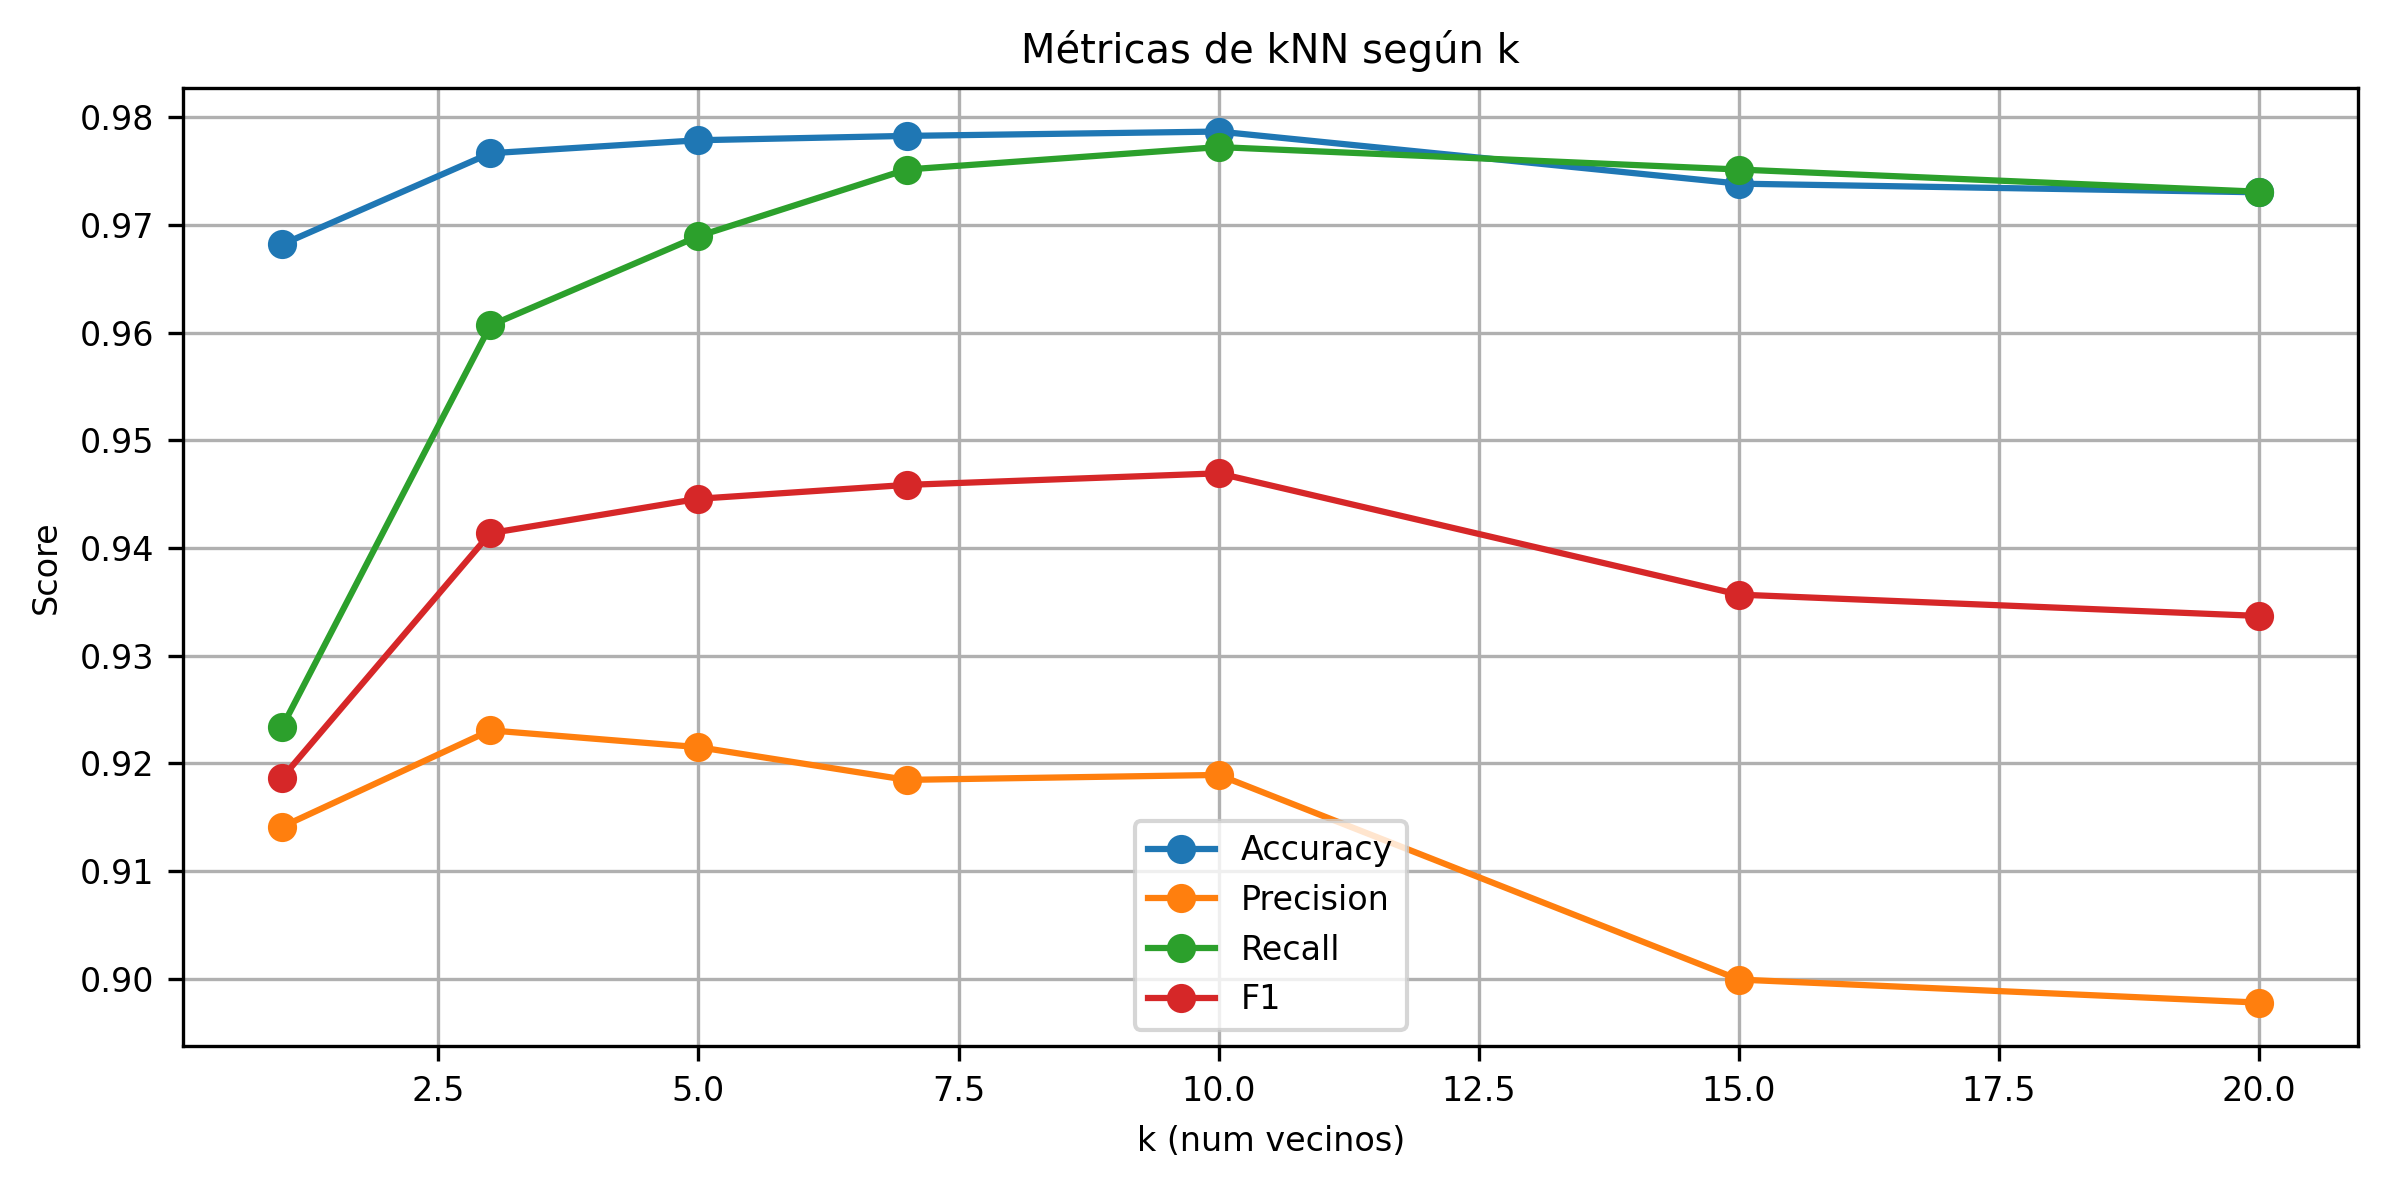

In [49]:
fig, ax = plt.subplots(figsize=(8, 4))
for metric in ['accuracy', 'precision', 'recall', 'f1']: ax.plot(results_df['k'], results_df[metric], marker='o', label=metric.capitalize())
ax.set_xlabel('k (num vecinos)')
ax.set_ylabel('Score')
ax.set_title('Métricas de kNN según k')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


## Cierre

En esta actividad vimos que evaluar un clasificador no consiste solo en obtener un score alto, sino en interpretar qué está midiendo cada métrica y cómo se construyen los conjuntos de validación. En este problema, el uso de validación cruzada estratificada fue importante para obtener una evaluación más estable y representativa.

También observamos que un modelo más complejo no siempre generaliza mejor. Aunque el árbol base ajustaba perfectamente los datos de entrenamiento, un árbol más simple logró mejores resultados en validación cruzada, lo que sugiere que reducir la complejidad ayudó a disminuir el sobreajuste.